The purpose of this notebook is to test the functions used to run the isotope model:

$$
\begin{align}
\frac{dC_{12}}{dt} &= S_{12} - \tau_{12}^{-1} C_{12} \\
\frac{dC_{13}}{dt} &= S_{13} - \tau_{13}^{-1} C_{13} \\
\end{align}
$$

The reaction rates are related by $k_{12} = \alpha k_{13}$, where $\alpha$ is the kinetic isotope effect (KIE). $\alpha > 1$ because $^{13}C$-methane has a longer lifetime than $^{12}C$-methane due to isotopic fractionation by the sink. Define perturbations about a steady state $\overline{C_{12}}$ and $\overline{C_{13}}$. Let $\varepsilon$ be the forcing common to the two isotopologues with $\beta$ as the mean emission ratio of $^{13}C/^{12}C$ methane. Let $\xi$ be the forcing specific to $^{13}C$ methane:

$$
\begin{align}

\frac{dC'_{12}}{dt} &= -\tau_{12}^{-1}C'_{12} + \varepsilon \\
\frac{dC'_{13}}{dt} &= -\alpha \tau_{12}^{-1} C'_{13} + \beta \varepsilon + \xi

\end{align}
$$

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

In [2]:
## helper for solutions
def to_xr_dataset(
    C12: np.ndarray,
    C13: np.ndarray,
    dt: float,
    *,
    epsilon: np.ndarray | None = None,
    xi: np.ndarray | None = None,
    delta: np.ndarray | None = None,
    C12_bar: float | None = None,
    C13_bar: float | None = None,
    time_units: str = "years",
) -> xr.Dataset:
    """
    Package simulation arrays into an xarray.Dataset with dims (time, ensemble).

    Parameters
    ----------
    C12, C13 : ndarray, shape (n_ens, n_steps) or (n_steps, n_ens)
        Bulk and 13C methane perturbations (ppb).
    dt : float
        Time step size. Time coordinate will be 0, dt, 2*dt, ... .
    epsilon : ndarray, optional
        Common forcing state (ppb/yr). Include if you simulated it.
    xi : ndarray, optional
        Isotopic-differential forcing state (ppb/yr). Include if applicable.
    delta : ndarray, optional
        Delta-notation perturbation (‰). If not provided, it will be computed
        when both C12_bar and C13_bar are supplied.
    C12_bar, C13_bar : float, optional
        Means for computing delta when `delta` is not provided:
        delta' = 1000 * (C13/C13_bar - C12/C12_bar).
        If C13_bar is None, 0.011 * C12_bar is used.
    time_units : str, default "years"
        Units label for the time coordinate.

    Returns
    -------
    ds : xr.Dataset
        Dataset with dims ('time', 'ensemble') and variables C12, C13, delta,
        and (if passed) epsilon, xi.
    """
    def _ensure_time_ens(a: np.ndarray, n_steps_ref: int | None = None, n_ens_ref: int | None = None) -> np.ndarray:
        a = np.asarray(a)
        if a.ndim == 1:
            # assume (n_steps,) -> make (n_steps, 1)
            a = a[:, None]
        # detect orientation; prefer (n_steps, n_ens)
        if a.shape[0] < a.shape[1]:  # likely (n_ens, n_steps)
            a = a.T
        # sanity check vs reference, if given
        if n_steps_ref is not None and a.shape[0] != n_steps_ref:
            raise ValueError(f"inconsistent n_steps: got {a.shape[0]} vs {n_steps_ref}")
        if n_ens_ref is not None and a.shape[1] != n_ens_ref:
            raise ValueError(f"inconsistent n_ens: got {a.shape[1]} vs {n_ens_ref}")
        return a

    # Normalize C12/C13
    C12_arr = _ensure_time_ens(C12)
    C13_arr = _ensure_time_ens(C13, n_steps_ref=C12_arr.shape[0], n_ens_ref=C12_arr.shape[1])
    n_steps, n_ens = C12_arr.shape

    # Optional drivers
    eps_arr = _ensure_time_ens(epsilon, n_steps, n_ens) if epsilon is not None else None
    xi_arr  = _ensure_time_ens(xi,      n_steps, n_ens) if xi is not None else None

    # delta: use provided, or compute if means given
    if delta is not None:
        delta_arr = _ensure_time_ens(delta, n_steps, n_ens)
    else:
        delta_arr = None
        if (C12_bar is not None):
            C13_bar_eff = C13_bar if C13_bar is not None else 0.011 * C12_bar
            delta_arr = 1000.0 * (C13_arr / C13_bar_eff - C12_arr / C12_bar)

    # coords
    time = np.arange(n_steps) * dt
    ens  = np.arange(n_ens)

    # build dataset
    data_vars = {
        "C12":     (("time", "ensemble"), C12_arr, {"units": "ppb"}),
        "C13":     (("time", "ensemble"), C13_arr, {"units": "ppb"}),
    }
    if delta_arr is not None:
        data_vars["delta"] = (("time", "ensemble"), delta_arr, {"units": "‰"})
    if eps_arr is not None:
        data_vars["epsilon"] = (("time", "ensemble"), eps_arr, {"units": "ppb/yr"})
    if xi_arr is not None:
        data_vars["xi"] = (("time", "ensemble"), xi_arr, {"units": "ppb/yr"})

    ds = xr.Dataset(
        data_vars=data_vars,
        coords={"time": ("time", time, {"units": time_units}), "ensemble": ("ensemble", ens)},
        attrs={"dt": dt, "description": "Methane isotope simulation output"},
    )
    return ds

# Case 1: No isotopologue-specific forcing ($\xi = 0$)
Perhaps a common forcing and the isotopic discrimination is enough for the simulation to reproduce the observed isotopic variations?

In [3]:
"""
Minimal van-Loan simulator for CH4 + 13CH4 with ONLY a common forcing epsilon.
State x = [C12', C13', eps]^T
d/dt:
  C12' = -(1/tau12)*C12' + eps
  C13' = -(1/tau13)*C13' + beta*eps
  eps  = -(1/tau_eps)*eps + sigma_eps * dW   (OU; set tau_eps small to approach white)
"""

from __future__ import annotations
import numpy as np
from numpy.typing import NDArray
from scipy import linalg

# ---------- Build continuous-time A, B ----------
def build_AB(tau12: float, alpha: float, beta: float, tau_eps: float, sigma_eps: float = 1.0
            ) -> tuple[NDArray[np.floating], NDArray[np.floating]]:
    """
    Return continuous-time (A, B) for the 3-state system with OU epsilon.

    Parameters
    ----------
    tau12 : float
        e-folding (years) of bulk CH4.
    alpha : float
        tau13 / tau12 (>1 means 13CH4 lives longer).
    beta : float
        Emission/forcing scale into 13CH4 relative to 12CH4.
    tau_eps : float
        OU timescale (years) of epsilon. Use small (e.g., 1 yr) for near-white.
    sigma_eps : float, default 1.0
        Innovation intensity (per sqrt(time)) feeding epsilon’s OU.

    Returns
    -------
    A : (3,3) ndarray
    B : (3,1) ndarray  (diffusion only into eps)
    """
    tau13 = alpha * tau12
    A = np.array([
        [-1.0/tau12,    0.0,         1.0],
        [   0.0,     -1.0/tau13,   beta ],
        [   0.0,        0.0,     -1.0/tau_eps]
    ], dtype=float)
    B = np.array([[0.0],[0.0],[sigma_eps]], dtype=float)
    return A, B

# ---------- Exact one-step (F, Q) via van Loan ----------
def discretize_van_loan(A, B, dt):
    """
    Exact discretization: F = expm(A dt),
    Q = ∫_0^dt exp(A s) B B^T exp(A^T s) ds  via block-exponential.
    """
    from scipy import linalg
    n = A.shape[0]
    BBt = B @ B.T
    M = np.block([[A, BBt],
                  [np.zeros_like(A), -A.T]])
    expM = linalg.expm(M * dt)
    F = expM[:n, :n]
    # Many refs define the top-right block as S with Q = F @ S
    Q = F @ expM[:n, n:]
    # Enforce symmetry to kill numerical skew
    Q = 0.5 * (Q + Q.T)
    return F, Q

# ---------- Stationary covariance ----------
def stationary_cov(F: NDArray[np.floating], Q: NDArray[np.floating]) -> NDArray[np.floating]:
    """Solve Σ = F Σ F^T + Q (requires spectral radius(F) < 1)."""
    return linalg.solve_discrete_lyapunov(F, Q)

# ---------- Calibrate epsilon intensity to hit Var(C12') ----------
def calibrate_sigma_eps_for_bulk_var(tau12: float, alpha: float, beta: float,
                                     tau_eps: float, dt: float, target_var_C12: float
                                    ) -> float:
    """
    Compute the sigma_eps (innovation intensity) needed so that stationary Var(C12') = target.
    Uses linearity: with sigma_eps=1, Var(C12') = v1; scale by sqrt(target/v1).
    """
    A, B = build_AB(tau12, alpha, beta, tau_eps, sigma_eps=1.0)
    F, Q = discretize_van_loan(A, B, dt)
    Σ = stationary_cov(F, Q)
    v1 = float(Σ[0, 0])
    if v1 <= 0:
        raise ValueError("Non-positive bulk variance for sigma_eps=1; check parameters.")
    return np.sqrt(target_var_C12 / v1)

# ---------- Simulation ----------
def _cov_sqrt_psd(Q, clip=0.0):
    """
    Return L such that L L^T ≈ Q, robust to semidefinite Q.
    Uses symmetric eigendecomposition with small negative eigenvalues clipped.
    """
    # Symmetrize numerically
    Qs = 0.5 * (Q + Q.T)
    lam, U = np.linalg.eigh(Qs)
    lam = np.clip(lam, clip, None)  # clip tiny negatives to 0
    L = U @ np.diag(np.sqrt(lam))
    return L

def simulate(F, Q, n_steps, n_ens=1, seed=None):
    """
    Simulate x_{t+1} = F x_t + w_t,  w_t ~ N(0, Q).
    Returns C12, C13, eps with shape (n_ens, n_steps).
    """
    rng = np.random.default_rng(seed)
    n = F.shape[0]
    L = _cov_sqrt_psd(Q, clip=0.0)  # no need for jitter
    x = np.zeros((n_ens, n_steps, n))
    for t in range(1, n_steps):
        z = rng.standard_normal(size=(n_ens, n)) @ L.T  # w_t
        x[:, t, :] = x[:, t-1, :] @ F.T + z
    return x[:, :, 0], x[:, :, 1], x[:, :, 2]


In [4]:
# Baseline params
tau12 = 10.0         # years
alpha = 1.004         # tau13/tau12 (KIE)
beta  = 0.01          # ~10% 13C/12C
tau_eps = 0.01        # OU forcing time scale 0.1 for near-white
dt = 0.01
n_years = 1000
n_ens = 5

# Calibrate epsilon innovation to hit Var(C12') ~ 100 ppb^2
target_var = 100.0
sigma_eps = calibrate_sigma_eps_for_bulk_var(tau12, alpha, beta, tau_eps, dt, target_var)

# Build discrete model with calibrated sigma_eps
A, B = build_AB(tau12, alpha, beta, tau_eps, sigma_eps=sigma_eps)
F, Q = discretize_van_loan(A, B, dt)

# Simulate 2000 steps, n members
C12, C13, eps = simulate(F, Q, n_steps=int(n_years/dt), n_ens=n_ens, seed=42)

# Example: delta' time series (linearized) if you want it:
C12_bar = 700.0
C13_bar = beta * C12_bar
# Build dataset; compute delta inside using means
ds = to_xr_dataset(
    C12=C12, C13=C13, epsilon=eps, xi=None, dt=dt,
    C12_bar=C12_bar, C13_bar=C13_bar  # uses 0.011*C12_bar if None
)
print("Sim ok. C12 var (empirical) ~", float(np.var(C12[0, 500:])))

Sim ok. C12 var (empirical) ~ 213.23439890066777


(-0.21, 0.21)

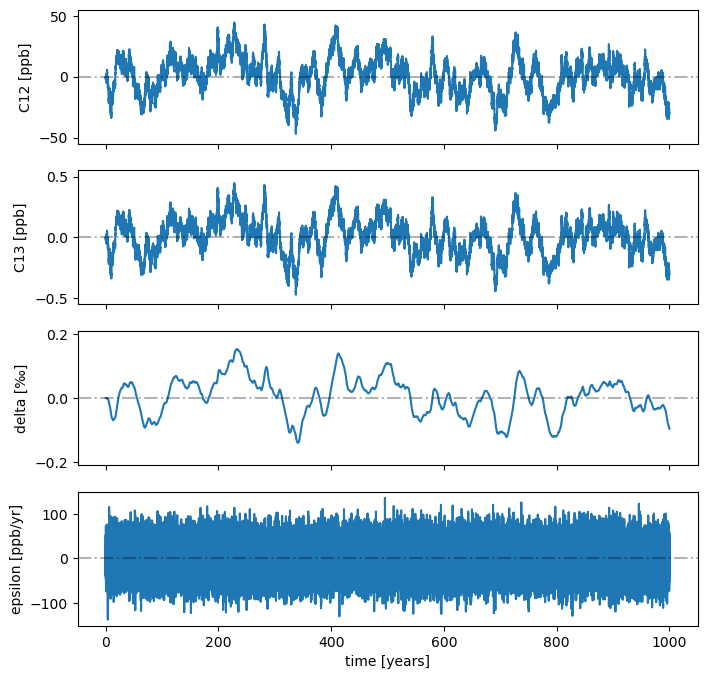

In [5]:
idx_ens = 0

fig, axs = plt.subplots(4, 1, figsize=(8, 8), sharex=True)
axs = axs.flatten()
ds.isel(ensemble=idx_ens)["C12"].plot(ax=axs[0], label="C12")
ds.isel(ensemble=idx_ens)["C13"].plot(ax=axs[1], label="C13")
ds.isel(ensemble=idx_ens)["delta"].plot(ax=axs[2], label="delta")
ds.isel(ensemble=idx_ens)["epsilon"].plot(ax=axs[3], label="epsilon")
for ax in axs:
    ax.set_title("")
    ax.axhline(0, color='k', ls='-.', alpha=0.3)
    if ax is not axs[-1]:
        ax.set_xlabel("")

axs[0].set_ylim(-55, 55)
axs[1].set_ylim(-0.55, 0.55)
axs[2].set_ylim(-0.21, 0.21)

In isolation, the delta variability just looks like a smoothed version of the $^{12}C$ and $^{13}C$ variability.

## Does smoothing the signal change things?
Real signal contains smoothing from the firn. Does using smoothed 12C and 13C signals change the results? 

Technically, the firn smoothing filter should be slightly different to account for molecular diffusion differences, but this should be pretty minor.

In [6]:
from hydra import compose, initialize
from methane_noise_forcing.core import FirnFilter, sample_series_at_core_points

with initialize(version_base=None, config_path="../../configs"):  # configs with data paths
    cfg = compose(
        config_name="config",
        overrides=[
            "+firn_kernel=firn_model_wais",
        ],
    )
firn_filter = FirnFilter.fit_from_config(
    kernel_type=cfg.firn_kernel.type,
    parameters=cfg.firn_kernel.parameters,
    path_root=cfg.paths.firn_filters_root,
)

# Apply firn smoothing to C12 and C13 time series
ds_smooth = []
for idx_ens in range(n_ens):
    C12_smooth = firn_filter.apply(ds["C12"].isel(ensemble=idx_ens).values, dt_series=dt)
    C13_smooth = firn_filter.apply(ds["C13"].isel(ensemble=idx_ens).values, dt_series=dt)
    ds_smooth.append(to_xr_dataset(
        C12=C12_smooth, C13=C13_smooth, epsilon=eps[idx_ens, :], xi=None, dt=dt,
        C12_bar=C12_bar, C13_bar=C13_bar  # uses 0.011*C12_bar if None
    ).assign_coords(ensemble=[idx_ens]))
ds_smooth = xr.concat(ds_smooth, dim="ensemble")

(-0.21, 0.21)

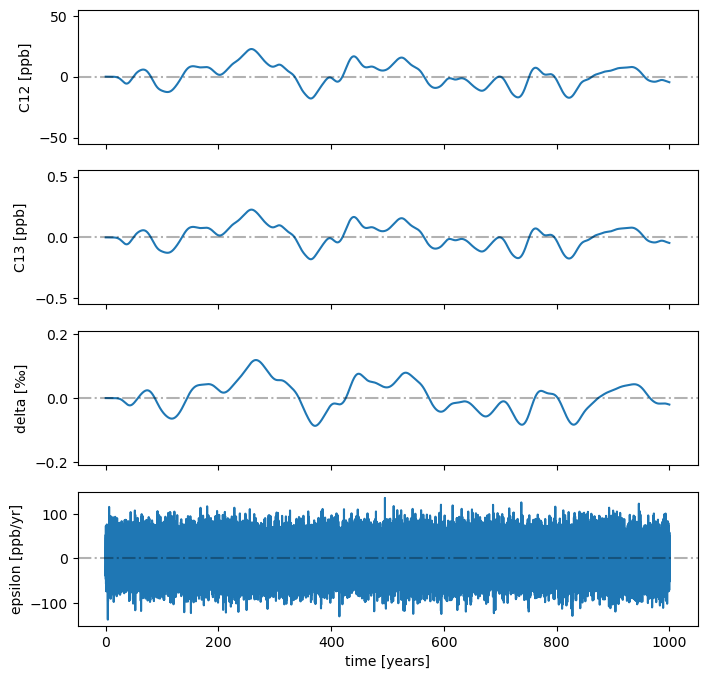

In [7]:
idx_ens = 0

fig, axs = plt.subplots(4, 1, figsize=(8, 8), sharex=True)
axs = axs.flatten()
ds_smooth.isel(ensemble=idx_ens)["C12"].plot(ax=axs[0], label="C12")
ds_smooth.isel(ensemble=idx_ens)["C13"].plot(ax=axs[1], label="C13")
ds_smooth.isel(ensemble=idx_ens)["delta"].plot(ax=axs[2], label="delta")
ds_smooth.isel(ensemble=idx_ens)["epsilon"].plot(ax=axs[3], label="epsilon")
for ax in axs:
    ax.set_title("")
    ax.axhline(0, color='k', ls='-.', alpha=0.3)
    if ax is not axs[-1]:
        ax.set_xlabel("")

axs[0].set_ylim(-55, 55)
axs[1].set_ylim(-0.55, 0.55)
axs[2].set_ylim(-0.21, 0.21)

Smoothing kind of changes things in the sense that the output signals are a lot smoother, so the variability in the delta signal looks pretty much the same as the variability in the 12C and 13C signals. The relative magnitude of the variability is about half of what it was before smoothing.

The variability is a bit more low frequency, as expected. Additionally, the samples density in Sapart et al. 2012 is only about n=25 per 1,000 years, so it is definitely possible that the observed centennial-scale variability is just a smoothed version of higher-frequency variability.

In [8]:
from pathlib import Path
import pandas as pd
data_dir = Path(cfg.paths.observations_root)

obs_sapart = pd.read_csv(
    data_dir / "raw/d13CH4 NEEM Sapart.txt",
    sep="\t",
    skiprows=4,
    names=["gas_age", "d13ch4"],
)
# sort descending by age
obs_sapart = obs_sapart.sort_values("gas_age", ascending=False).reset_index(drop=True)

# detrend
for col in ["d13ch4"]:
    p = np.polyfit(obs_sapart["gas_age"], obs_sapart[col], 1)
    trend = np.polyval(p, obs_sapart["gas_age"])
    obs_sapart[f"{col}_anomaly"] = obs_sapart[col] - trend

In [9]:
# try sampling
idx_ens = 0
ds_delta = ds_smooth.isel(ensemble=idx_ens)["delta"]
ds_delta_sampled = sample_series_at_core_points(
    series_time = ds_delta["time"].values,
    core_time = obs_sapart[obs_sapart["gas_age"] > 1000]["gas_age"].values,
    series_to_sample = ds_delta.values,
    core_offset_flag = "start"
)

(-0.21, 0.21)

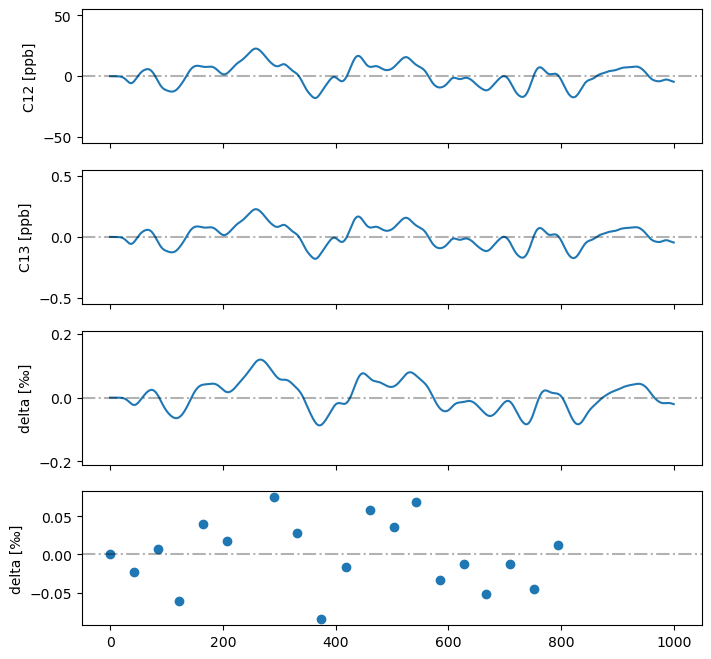

In [10]:
idx_ens = 0

fig, axs = plt.subplots(4, 1, figsize=(8, 8), sharex=True)
axs = axs.flatten()
ds_smooth.isel(ensemble=idx_ens)["C12"].plot(ax=axs[0], label="C12")
ds_smooth.isel(ensemble=idx_ens)["C13"].plot(ax=axs[1], label="C13")
ds_smooth.isel(ensemble=idx_ens)["delta"].plot(ax=axs[2], label="delta")
# ds_smooth.isel(ensemble=idx_ens)["epsilon"].plot(ax=axs[3], label="epsilon")
axs[3].plot(
    obs_sapart[obs_sapart["gas_age"] > 1000]["gas_age"].values - 1009,
ds_delta_sampled,
marker='o',
linestyle='none',
)
axs[3].set_ylabel("delta [‰]")
for ax in axs:
    ax.set_title("")
    ax.axhline(0, color='k', ls='-.', alpha=0.3)
    if ax is not axs[-1]:
        ax.set_xlabel("")

axs[0].set_ylim(-55, 55)
axs[1].set_ylim(-0.55, 0.55)
axs[2].set_ylim(-0.21, 0.21)

## Which parameters is this sensitive to?

I wonder if in this simple case, the results are sensitive to the ratio of the lifetimes (KIE; $\alpha$), the mean isotopic ratio of emissions ($\beta$), the timescale of the common forcing ($\tau_{\varepsilon}$), or the lifetime of the bulk methane itself?

Save smoothed and unsmoothed results for comparison.

In [11]:
def change_parameter(param_name, param_value, params_base):
    # Create a copy of the current parameters
    params = params_base.copy()
    if param_name != "base":
        # Modify the specified parameter
        params[param_name] = param_value
    return params

target_var = 100
n_ens = 1
param_changes = {
    "base": None,
    "tau12": 5,
    "alpha": 1.06,
    "beta": 0.1,
    "tau_eps": 10.0,
}
params_base = {
    "tau12": 10,
    "alpha": 1.004,
    "beta": 0.01,
    "tau_eps": 0.01,
}

simulations = []
simulations_smooth = []
for param_name, param_value in param_changes.items():
    params = change_parameter(param_name, param_value, params_base=params_base)
    # Calibrate epsilon innovation to hit Var(C12') ~ 100 ppb^2
    sigma_eps = calibrate_sigma_eps_for_bulk_var(
        tau12=params["tau12"], 
        alpha=params["alpha"], 
        beta=params["beta"],
        tau_eps=params["tau_eps"], 
        dt=dt, 
        target_var_C12=target_var
    )
    # calibrate_sigma_eps_for_bulk_var(tau12, alpha, beta, tau_eps, dt, target_var)
    # Build discrete model with calibrated sigma_eps
    A, B = build_AB(
        tau12=params["tau12"], 
        alpha=params["alpha"],
        beta=params["beta"], 
        tau_eps=params["tau_eps"],
        sigma_eps=sigma_eps
    )
    F, Q = discretize_van_loan(A, B, dt)
    # Simulate
    C12, C13, eps = simulate(F, Q, n_steps=int(n_years/dt), n_ens=n_ens, seed=42)
    ds_param = to_xr_dataset(
        C12=C12, C13=C13, epsilon=eps, xi=None, dt=dt,
        C12_bar=C12_bar, C13_bar=params["beta"]*C12_bar
    )
    print(f"Changed {param_name} to {param_value}. C12 var (empirical) ~", float(np.var(C12[0, 500:])))

    # Smooth 
    C12_smooth = firn_filter.apply(ds_param["C12"].isel(ensemble=0).values, dt_series=dt)
    C13_smooth = firn_filter.apply(ds_param["C13"].isel(ensemble=0).values, dt_series=dt)
    ds_param_smooth = to_xr_dataset(
        C12=C12_smooth, C13=C13_smooth, epsilon=eps, xi=None, dt=dt,
        C12_bar=C12_bar, C13_bar=params["beta"]*C12_bar
    )
    # Append
    simulations.append(ds_param.expand_dims(param=[param_name]))
    simulations_smooth.append(ds_param_smooth.expand_dims(param=[param_name]))

simulations = xr.concat(simulations, dim="param")
simulations_smooth = xr.concat(simulations_smooth, dim="param")

Changed base to None. C12 var (empirical) ~ 267.0502525142728
Changed tau12 to 5. C12 var (empirical) ~ 237.63627909691743
Changed alpha to 1.06. C12 var (empirical) ~ 267.0502525134647
Changed beta to 0.1. C12 var (empirical) ~ 267.0494369625472
Changed tau_eps to 10.0. C12 var (empirical) ~ 146.40387944050562


Text(0.5, 0, 'Time (years)')

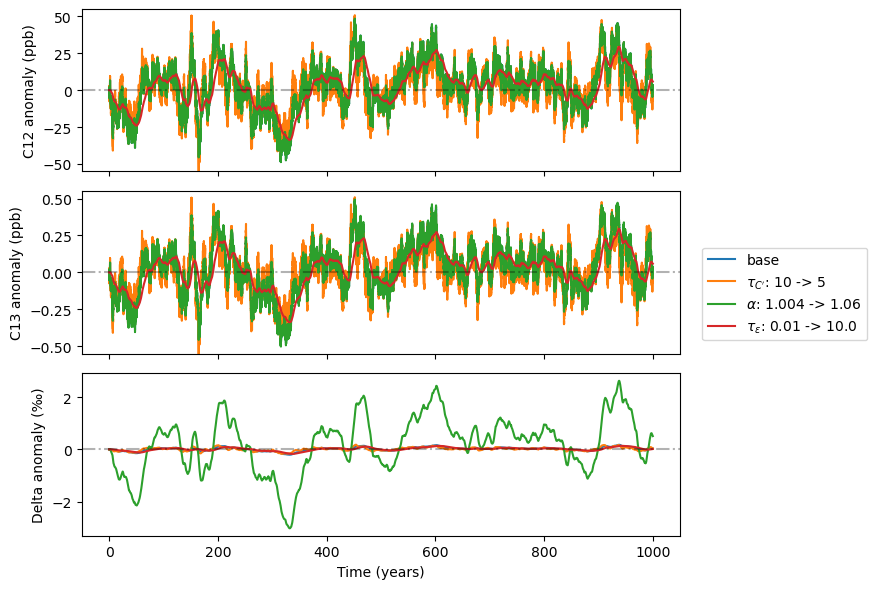

In [12]:
## Plot 12C and delta for each parameter
params_plot = [
    "base",
    "tau12", 
    "alpha", 
    # "beta", 
    "tau_eps"
]
label_mapper = {
    "tau12": "$\\tau_{C'}$",
    "alpha": "$\\alpha$",
    "beta": "$\\beta$",
    "tau_eps": "$\\tau_{\\varepsilon}$",
}

fig, axs = plt.subplots(3, 1, figsize=(7, 6), sharex=True, tight_layout=True)
axs = axs.flatten()
time = simulations["time"].values

for param_name in params_plot:
    if param_name != "base":
        label = f"{label_mapper[param_name]}: {params_base[param_name]} -> {param_changes[param_name]}"
    else:
        label = "base"
    axs[0].plot(
        time, 
        simulations.sel(param=param_name).isel(ensemble=0)["C12"], 
        label=label
    )
    axs[1].plot(
        time,
        simulations.sel(param=param_name).isel(ensemble=0)["C13"]
    )
    axs[2].plot(
        time, 
        simulations.sel(param=param_name).isel(ensemble=0)["delta"]
    )

for ax in axs:
    ax.axhline(0, color='k', ls='-.', alpha=0.3)
    ax.set_title("")
    ax.set_xlabel("")
fig.legend(loc='center left', bbox_to_anchor=(1, 0.5))

axs[0].set_ylim(-55, 55)
axs[1].set_ylim(-0.55, 0.55)

axs[0].set_ylabel('C12 anomaly (ppb)')
axs[1].set_ylabel('C13 anomaly (ppb)')
axs[2].set_ylabel('Delta anomaly (‰)')
axs[-1].set_xlabel("Time (years)")

Alpha, which is directly controlled by the kinetic isotope effect, has the largest lever on the results.

# Case 2: With isotopologue-specific forcing ($\xi \neq 0$)

In [13]:
# -*- coding: utf-8 -*-
"""
CH4 + 13CH4 with common forcing epsilon and independent isotopic forcing xi.
State x = [C12', C13', eps, xi]^T

d/dt:
  C12' = -(1/tau12)*C12' + eps
  C13' = -(1/tau13)*C13' + beta*eps + xi
  eps  = -(1/tau_eps)*eps + sigma_eps * dW1
  xi   = -(1/tau_xi) *xi  + sigma_xi  * dW2
"""

from __future__ import annotations
import numpy as np
from numpy.typing import NDArray
from scipy import linalg

# ---------- Build continuous-time A, B ----------
def build_AB_eps_xi(
    tau12: float,
    alpha: float,
    beta:  float,
    tau_eps: float,
    tau_xi:  float,
    sigma_eps: float = 1.0,
    sigma_xi:  float = 0.0,
) -> tuple[NDArray[np.floating], NDArray[np.floating]]:
    """
    Return continuous-time (A, B) for the 4-state system with OU epsilon and OU xi.

    Parameters
    ----------
    tau12 : float
        E-folding (years) of bulk CH4.
    alpha : float
        tau13 / tau12 (>1 means 13CH4 lives longer), so tau13 = alpha * tau12.
    beta : float
        Coupling of epsilon into 13CH4 relative to 12CH4.
    tau_eps : float
        OU timescale (years) of epsilon; small -> near-white.
    tau_xi : float
        OU timescale (years) of xi (isotope-specific).
    sigma_eps : float, default 1.0
        Diffusion intensity for epsilon (units of state / sqrt(year)).
    sigma_xi : float, default 0.0
        Diffusion intensity for xi (units of state / sqrt(year)).

    Returns
    -------
    A : (4, 4) ndarray
    B : (4, 2) ndarray   (diffusion columns correspond to eps, xi)
    """
    tau13 = alpha * tau12
    A = np.array([
        [-1.0/tau12,   0.0,          1.0,  0.0],   # C12'  <- + eps
        [   0.0,    -1.0/tau13,    beta,  1.0],    # C13'  <- + beta*eps + xi
        [   0.0,       0.0,     -1.0/tau_eps, 0.0],# eps   OU
        [   0.0,       0.0,         0.0,  -1.0/tau_xi], # xi OU
    ], dtype=float)
    B = np.array([
        [0.0,       0.0],
        [0.0,       0.0],
        [sigma_eps, 0.0],
        [0.0,       sigma_xi],
    ], dtype=float)
    return A, B

# ---------- Exact one-step (F, Q) via van Loan ----------
def discretize_van_loan(A: NDArray[np.floating], B: NDArray[np.floating], dt: float
                       ) -> tuple[NDArray[np.floating], NDArray[np.floating]]:
    """
    Exact discretization: F = expm(A dt),
    Q = ∫_0^dt exp(A s) B B^T exp(A^T s) ds  via block-exponential.
    """
    n = A.shape[0]
    BBt = B @ B.T
    M = np.block([[A, BBt],
                  [np.zeros_like(A), -A.T]])
    expM = linalg.expm(M * dt)
    F = expM[:n, :n]
    Q = F @ expM[:n, n:]
    Q = 0.5 * (Q + Q.T)  # symmetrize to remove numerical skew
    return F, Q

# ---------- Stationary covariance ----------
def stationary_cov(F: NDArray[np.floating], Q: NDArray[np.floating]) -> NDArray[np.floating]:
    """Solve Σ = F Σ F^T + Q (requires spectral radius(F) < 1)."""
    return linalg.solve_discrete_lyapunov(F, Q)

# ---------- PSD-safe covariance square-root ----------
def _cov_sqrt_psd(Q: NDArray[np.floating], clip: float = 0.0) -> NDArray[np.floating]:
    """
    Return L such that L L^T ≈ Q, robust to positive-semidefinite Q.
    Uses symmetric eigendecomposition; clips tiny negative eigenvalues.
    """
    Qs = 0.5 * (Q + Q.T)
    lam, U = np.linalg.eigh(Qs)
    lam = np.clip(lam, clip, None)
    return U @ np.diag(np.sqrt(lam))

# ---------- Simulation ----------
def simulate(F: NDArray[np.floating], Q: NDArray[np.floating], n_steps: int,
             n_ens: int = 1, seed: int | None = None
            ) -> tuple[NDArray[np.floating], NDArray[np.floating], NDArray[np.floating], NDArray[np.floating]]:
    """
    Simulate x_{t+1} = F x_t + w_t,  w_t ~ N(0, Q).

    Returns
    -------
    C12, C13, eps, xi : arrays of shape (n_ens, n_steps)
    """
    rng = np.random.default_rng(seed)
    n = F.shape[0]
    L = _cov_sqrt_psd(Q)
    x = np.zeros((n_ens, n_steps, n))
    for t in range(1, n_steps):
        w = rng.standard_normal(size=(n_ens, n)) @ L.T
        x[:, t, :] = x[:, t-1, :] @ F.T + w
    return x[:, :, 0], x[:, :, 1], x[:, :, 2], x[:, :, 3]

# ---------- Calibrate sigma_eps to hit Var(C12') (bulk) ----------
def calibrate_sigma_eps_for_bulk_var(
    tau12: float, alpha: float, beta: float,
    tau_eps: float, tau_xi: float,
    dt: float, target_var_C12: float,
    sigma_xi: float = 0.0
) -> float:
    """
    Choose sigma_eps so stationary Var(C12') = target, with given xi settings.

    Notes
    -----
    Bulk variance is driven by the epsilon path only in this model,
    but we allow a nonzero xi so you can keep your xi settings intact.
    """
    A, B = build_AB_eps_xi(tau12, alpha, beta, tau_eps, tau_xi,
                           sigma_eps=1.0, sigma_xi=sigma_xi)
    F, Q = discretize_van_loan(A, B, dt)
    Sigma = stationary_cov(F, Q)
    v1 = float(Sigma[0, 0])  # Var(C12') at sigma_eps=1
    if v1 <= 0:
        raise ValueError("Non-positive bulk variance for sigma_eps=1; check parameters.")
    return float(np.sqrt(target_var_C12 / v1))

# ---------- Calibrate sigma_xi to hit Var(delta') (with eps fixed) ----------
def calibrate_sigma_xi_for_delta_var(
    tau12: float, alpha: float, beta: float,
    tau_eps: float, tau_xi: float,
    dt: float,
    C12_bar: float, C13_bar: float | None,
    target_var_delta: float,
    sigma_eps: float,
    baseline_sigma_xi: float = 0.0
) -> float:
    """
    Given fixed sigma_eps (already bulk-calibrated), find sigma_xi to reach Var(delta') target.

    Strategy
    --------
    1) Compute Var(delta') with baseline xi intensity (often 0).
    2) Compute Var(delta') with unit xi intensity (keeping eps fixed).
    3) Use linearity in innovation variance to scale sigma_xi.

    Returns
    -------
    sigma_xi : float
        Diffusion intensity for xi that (approximately) attains target Var(delta').
    """
    if C13_bar is None:
        C13_bar = 0.011 * C12_bar
    Ldelta = np.array([-1000.0/C12_bar, 1000.0/C13_bar, 0.0, 0.0])

    # Baseline
    A0, B0 = build_AB_eps_xi(tau12, alpha, beta, tau_eps, tau_xi,
                             sigma_eps=sigma_eps, sigma_xi=baseline_sigma_xi)
    F0, Q0 = discretize_van_loan(A0, B0, dt)
    S0 = stationary_cov(F0, Q0)
    var_base = float(Ldelta @ S0 @ Ldelta)

    # Unit xi
    A1, B1 = build_AB_eps_xi(tau12, alpha, beta, tau_eps, tau_xi,
                             sigma_eps=sigma_eps, sigma_xi=1.0)
    F1, Q1 = discretize_van_loan(A1, B1, dt)
    S1 = stationary_cov(F1, Q1)
    var_unit = float(Ldelta @ S1 @ Ldelta) - var_base

    if var_unit <= 0:
        return 0.0

    need = target_var_delta - var_base
    if need <= 0:
        return 0.0

    return float(np.sqrt(need / var_unit))

# ---------- Utility: delta series ----------
def delta_series(C12: NDArray[np.floating], C13: NDArray[np.floating],
                 C12_bar: float, C13_bar: float | None = None) -> NDArray[np.floating]:
    """
    Compute linearized delta': 1000 * (C13/C13_bar - C12/C12_bar).
    Arrays are (n_ens, n_steps).
    """
    if C13_bar is None:
        C13_bar = 0.011 * C12_bar
    return 1000.0 * (C13 / C13_bar - C12 / C12_bar)


In [14]:
# Baseline params
tau12 = 10.0          # years
alpha = 1.004         # tau13/tau12 (KIE)
beta  = 0.01          # ~10% 13C/12C
tau_eps = 0.01        # OU forcing time scale 0.1 for near-white
tau_xi = 0.01         # OU timescale for independent forcing on 13C
dt = 0.01
n_years = 1000
n_ens = 5

# Calibrate epsilon innovation to hit Var(C12') ~ 100 ppb^2
target_var = 100.0
sigma_eps = calibrate_sigma_eps_for_bulk_var(tau12, alpha, beta, tau_eps, tau_xi, dt, target_var_C12=target_var, sigma_xi=0.0)

# Calibrate xi innovation to hit
target_var_delta = 1.38**2 # about 0.5**2 in sapart
sigma_xi = calibrate_sigma_xi_for_delta_var(
    tau12, alpha, beta, tau_eps, tau_xi, dt,
    C12_bar=700.0, C13_bar=None,
    target_var_delta=target_var_delta,
    sigma_eps=sigma_eps,
    baseline_sigma_xi=0.0
)

# Build discrete model with calibrated sigma_eps and sigma_xi
A, B = build_AB_eps_xi(tau12, alpha, beta, tau_eps, tau_xi, sigma_eps=sigma_eps, sigma_xi=sigma_xi)
F, Q = discretize_van_loan(A, B, dt)

# Simulate 2000 steps, n members
C12, C13, eps, xi = simulate(F, Q, n_steps=int(n_years/dt), n_ens=n_ens, seed=42)

# Put into dataset
C12_bar = 700.0
C13_bar = beta * C12_bar
# Build dataset; compute delta inside using means
ds = to_xr_dataset(
    C12=C12, C13=C13, epsilon=eps, xi=xi, dt=dt,
    C12_bar=C12_bar, C13_bar=C13_bar  # uses 0.011*C12_bar if None
)

Text(0, 0.5, 'β * epsilon [ppb/yr]')

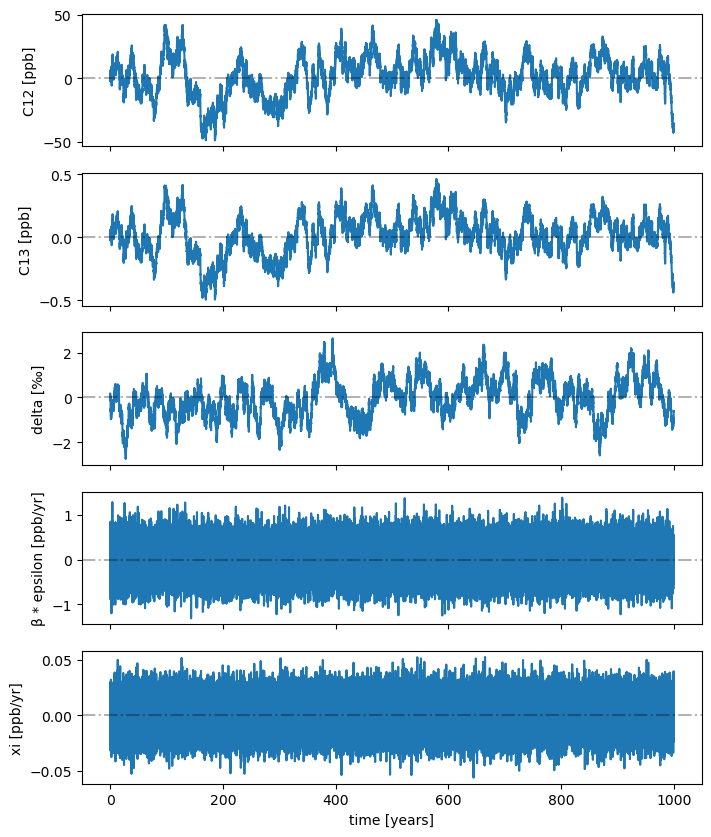

In [15]:
idx_ens = 2

fig, axs = plt.subplots(5, 1, figsize=(8, 10), sharex=True)
axs = axs.flatten()
ds.isel(ensemble=idx_ens)["C12"].plot(ax=axs[0], label="C12")
ds.isel(ensemble=idx_ens)["C13"].plot(ax=axs[1], label="C13")
ds.isel(ensemble=idx_ens)["delta"].plot(ax=axs[2], label="delta")
(ds.isel(ensemble=idx_ens)["epsilon"] * beta).plot(ax=axs[3], label="β*epsilon")
ds.isel(ensemble=idx_ens)["xi"].plot(ax=axs[4], label="xi")
for ax in axs:
    ax.set_title("")
    ax.axhline(0, color='k', ls='-.', alpha=0.3)
    if ax is not axs[-1]:
        ax.set_xlabel("")

axs[3].set_ylabel('β * epsilon [ppb/yr]')

Predictably, adding independent forcing 1) inflates the variance of the delta signal and 2) decouples the delta variations from the bulk methane variations. 

Take $\tau_{\xi} = \tau_{\varepsilon} = 0.01$ and $\beta = 1$. We will contrast case 1 ($\xi = 0$) with case 2 ($\xi \neq 0$).

In case 1, the std of delta is 0.06‰, while in case 2, the std of delta is 1.2‰. The correlation between delta and C13 drops from 0.73 to 0.03.

Interestingly, in case 2, the standard deviation of xi (0.02 ppb/yr) is much smaller than the standard deviation of beta*epsilon (0.32 ppb/yr), yet xi dominates the delta variability. This is because the common-mode forcing epsilon is largely removed from the delta signal by the isotopic discrimination (1 - 1/alpha) factor.

## Let's try smoothing and sampling
simulate a 2500-year record then firn-smooth and sample it like Sapart et al. 2012.

In [16]:
tau12 = 10.0          # years
alpha = 1.004         # tau13/tau12 (KIE)
beta  = 0.01          # ~10% 13C/12C
tau_eps = 0.01        # OU forcing time scale 0.1 for near-white
tau_xi = 10         # OU timescale for independent forcing on 13C
dt = 0.01
n_years = 2500
n_ens = 5

# Calibrate epsilon innovation to hit Var(C12') ~ 100 ppb^2
target_var = 100.0
sigma_eps = calibrate_sigma_eps_for_bulk_var(tau12, alpha, beta, tau_eps, tau_xi, dt, target_var_C12=target_var, sigma_xi=0.0)

# Calibrate xi innovation to hit
target_var_delta = 1.38**2 # about 0.5**2 in sapart
sigma_xi = calibrate_sigma_xi_for_delta_var(
    tau12, alpha, beta, tau_eps, tau_xi, dt,
    C12_bar=700.0, C13_bar=None,
    target_var_delta=target_var_delta,
    sigma_eps=sigma_eps,
    baseline_sigma_xi=0.0
)

# Build discrete model with calibrated sigma_eps and sigma_xi
A, B = build_AB_eps_xi(tau12, alpha, beta, tau_eps, tau_xi, sigma_eps=sigma_eps, sigma_xi=sigma_xi)
F, Q = discretize_van_loan(A, B, dt)

# Simulate 2000 steps, n members
C12, C13, eps, xi = simulate(F, Q, n_steps=int(n_years/dt), n_ens=n_ens, seed=42)

# Put into dataset
C12_bar = 700.0
C13_bar = beta * C12_bar
# Build dataset; compute delta inside using means
ds = to_xr_dataset(
    C12=C12, C13=C13, epsilon=eps, xi=xi, dt=dt,
    C12_bar=C12_bar, C13_bar=C13_bar  # uses 0.011*C12_bar if None
)

ds_smooth = []
for idx_ens in range(n_ens):
    C12_smooth = firn_filter.apply(ds["C12"].isel(ensemble=idx_ens).values, dt_series=dt)
    C13_smooth = firn_filter.apply(ds["C13"].isel(ensemble=idx_ens).values, dt_series=dt)
    ds_smooth.append(to_xr_dataset(
        C12=C12_smooth, C13=C13_smooth, epsilon=eps[idx_ens, :], xi=None, dt=dt,
        C12_bar=C12_bar, C13_bar=C13_bar  # uses 0.011*C12_bar if None
    ).assign_coords(ensemble=[idx_ens]))
ds_smooth = xr.concat(ds_smooth, dim="ensemble")

In [17]:
# check standard deviation of delta after smoothing
delta_smooth = ds_smooth["delta"].std(dim="time")
print(f"Post-smoothing delta' std (ppb): {float(delta_smooth.mean()):0.2f} ± {float(delta_smooth.std()):0.2f}")
print(f"Observed Sapart delta' std (ppb): {obs_sapart['d13ch4_anomaly'].std():0.2f}")

Post-smoothing delta' std (ppb): 0.45 ± 0.02
Observed Sapart delta' std (ppb): 0.48


Text(0, 0.5, 'β * epsilon [ppb/yr]')

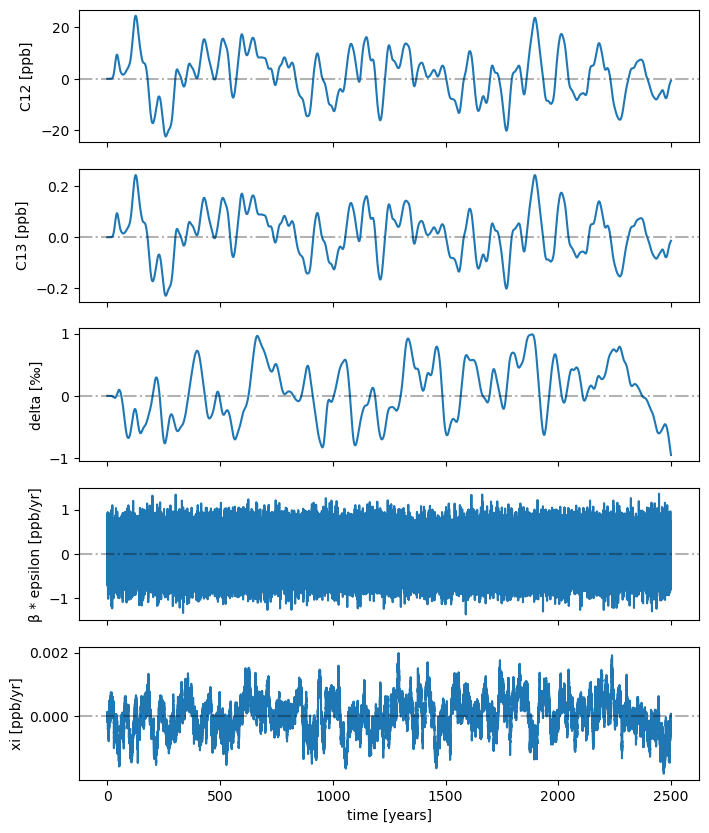

In [18]:
idx_ens = 0

fig, axs = plt.subplots(5, 1, figsize=(8, 10), sharex=True)
axs = axs.flatten()
ds_smooth.isel(ensemble=idx_ens)["C12"].plot(ax=axs[0], label="C12")
ds_smooth.isel(ensemble=idx_ens)["C13"].plot(ax=axs[1], label="C13")
ds_smooth.isel(ensemble=idx_ens)["delta"].plot(ax=axs[2], label="delta")
(ds.isel(ensemble=idx_ens)["epsilon"] * beta).plot(ax=axs[3], label="β*epsilon")
ds.isel(ensemble=idx_ens)["xi"].plot(ax=axs[4], label="xi")
for ax in axs:
    ax.set_title("")
    ax.axhline(0, color='k', ls='-.', alpha=0.3)
    if ax is not axs[-1]:
        ax.set_xlabel("")

axs[3].set_ylabel('β * epsilon [ppb/yr]')

In [19]:
# sample
ds_delta_sampled = []
for idx_ens in range(n_ens):
    da_delta = ds_smooth.isel(ensemble=idx_ens)["delta"]
    delta_sampled = sample_series_at_core_points(
        series_time = da_delta["time"].values,
        core_time = obs_sapart["gas_age"].values[::-1],
        series_to_sample = da_delta.values,
        core_offset_flag = "start"
    )
    da_delta_sampled = xr.DataArray(
        data=delta_sampled[:, np.newaxis],
        dims=["time", "ensemble"],
        coords={
            "time": obs_sapart["gas_age"].values[::-1] - obs_sapart["gas_age"].values[-1],
            "ensemble": [idx_ens],
        },
        name="delta_sampled"
    )
    ds_delta_sampled.append(da_delta_sampled)

ds_delta_sampled = xr.concat(ds_delta_sampled, dim="ensemble")

# check standard deviation of sampled delta
delta_sampled_std = ds_delta_sampled.std(dim="time")
print(f"Sampled delta' std (ppb): {float(delta_sampled_std.mean()):0.2f} ± {float(delta_sampled_std.std()):0.2f}")
print(f"Observed Sapart delta' std (ppb): {obs_sapart['d13ch4_anomaly'].std():0.2f}")

Sampled delta' std (ppb): 0.44 ± 0.04
Observed Sapart delta' std (ppb): 0.48


Text(0.5, 0, 'Time [years]')

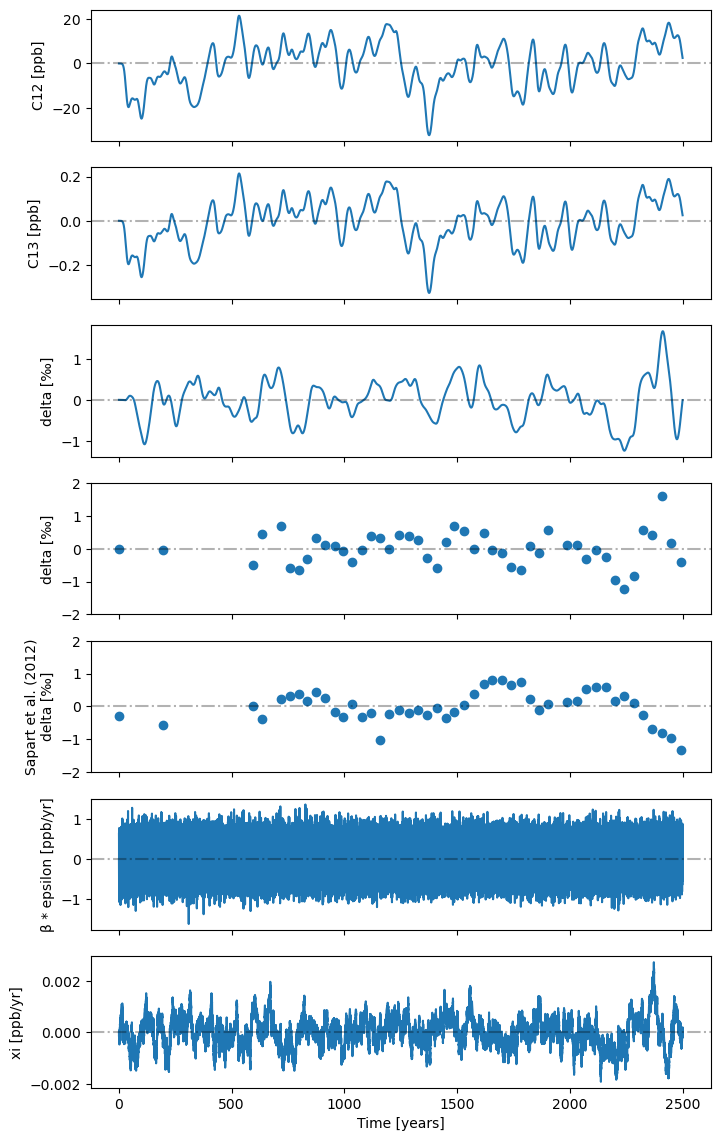

In [20]:
idx_ens = 3
plot_noise = True
ylim_sampled = (-2, 2)

n_subplots = 5
fig_length = 10
if plot_noise:
    n_subplots = 7
    fig_length = 14

fig, axs = plt.subplots(n_subplots, 1, figsize=(8, fig_length), sharex=True)
axs = axs.flatten()
ds_smooth.isel(ensemble=idx_ens)["C12"].plot(ax=axs[0], label="C12")
ds_smooth.isel(ensemble=idx_ens)["C13"].plot(ax=axs[1], label="C13")
ds_smooth.isel(ensemble=idx_ens)["delta"].plot(ax=axs[2], label="delta")
ds_delta_sampled.isel(ensemble=idx_ens).plot(ax=axs[3], label="delta sampled", linestyle='none', marker='o')
# also plot sapart data
axs[4].plot(
    ds_delta_sampled.time.values,
    obs_sapart["d13ch4_anomaly"].values[::-1],
    linestyle='none',
    marker='o',
)
if plot_noise:
    (ds.isel(ensemble=idx_ens)["epsilon"] * beta).plot(ax=axs[5], label="β*epsilon")
    ds.isel(ensemble=idx_ens)["xi"].plot(ax=axs[6], label="xi")
for ax in axs:
    ax.set_title("")
    ax.axhline(0, color='k', ls='-.', alpha=0.3)
    if ax is not axs[-1]:
        ax.set_xlabel("")

axs[3].set_ylim(ylim_sampled)
axs[4].set_ylim(ylim_sampled)

axs[3].set_ylabel('delta [‰]')
axs[4].set_ylabel('Sapart et al. (2012)\ndelta [‰]')
if plot_noise:
    axs[5].set_ylabel('β * epsilon [ppb/yr]')

axs[-1].set_xlabel("Time [years]")

"White noise" limit of xi doesn't produce pseudo-obs that look similar to the real data (too noisy) but increasing the timescale of xi to 1 year or above produces more realistic-looking pseudo-observations.